# Tugas 9 | Crawling Twiter (X)

## Deteksi Komunitas Pengguna Twitter (Dataset: hastag_250.csv)
Membangun graph berdasarkan mention (@username) dari tweet, lalu mendeteksi komunitas menggunakan metode Louvain.


import library

In [2]:
!pip install pandas networkx python-louvain matplotlib



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


load

In [ ]:
import pandas as pd
import ast
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import math

# Load CSV
df = pd.read_csv("hastag_250.csv")

print("Dataset berhasil dimuat!")
print("Jumlah Baris :", len(df))


Dataset berhasil dimuat!
Jumlah Baris : 10016


Ekstrak Mention (@username) sebagai Edge Graph

Mention di kolom tweet (pakai regex)

Reply-to user (pakai parsing list dict)

In [10]:
import re

def extract_mentions(tweet):
    if pd.isna(tweet):
        return []
    return re.findall(r"@([A-Za-z0-9_]+)", str(tweet))

def extract_reply_to(val):
    if pd.isna(val) or val == "[]":
        return []
    try:
        parsed = ast.literal_eval(val)
        return [x['screen_name'] for x in parsed]
    except:
        return []


tambahkan kolom

In [11]:
df["mentions"] = df["tweet"].apply(extract_mentions)
df["reply_users"] = df["reply_to"].apply(extract_reply_to)

df[["tweet", "mentions", "reply_users"]].head()


,tweet,mentions,reply_users
0,@GailAlfarATX @elonmusk @Tesla @teslacn @Tesla...,"[GailAlfarATX, elonmusk, Tesla, teslacn, Tesla...","[GailAlfarATX, elonmusk, Tesla, teslacn, Tesla..."
1,@elonmusk @GailAlfarATX @Tesla @teslacn @Tesla...,"[elonmusk, GailAlfarATX, Tesla, teslacn, Tesla...","[elonmusk, GailAlfarATX, Tesla, teslacn, Tesla..."
2,"@elonmusk #Think about buying a country , #Mex...","[elonmusk, Tesla, SafetyMentalst]",[]
3,"@get_innocuous Actual receipts, and yet you ha...",[get_innocuous],[get_innocuous]
4,Tesla wall battery for the save! Power went ou...,[],[]


Buat Graph: Node = username, Edge = mention → mentioned_user

In [12]:
G = nx.Graph()

for _, row in df.iterrows():
    user = str(row["username"])

    # mention di tweet
    for m in row["mentions"]:
        G.add_edge(user, m.lower())

    # reply-to
    for r in row["reply_users"]:
        G.add_edge(user, r.lower())


info dasar graph

In [13]:
print("=== INFO GRAPH ===")
print("Jumlah Node :", G.number_of_nodes())
print("Jumlah Edge :", G.number_of_edges())

degrees = dict(G.degree())

stats = {
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "avg_degree": sum(degrees.values()) / G.number_of_nodes(),
    "density": nx.density(G),
    "top_10_by_degree": sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
}

for k, v in stats.items():
    print(k, ":", v)


=== INFO GRAPH ===
Jumlah Node : 255
Jumlah Edge : 542
nodes : 255
edges : 542
avg_degree : 4.250980392156863
density : 0.01673614327620812
top_10_by_degree : [('elonmusk', 65), ('tesla', 52), ('gailalfaratx', 32), ('teslacn', 32), ('teslaownersebay', 32), ('blueskykites', 32), ('kristennetten', 32), ('jennicurrent', 32), ('daelmor', 32), ('ihearttesla', 32)]


Plot Degree Distribution (log-log)

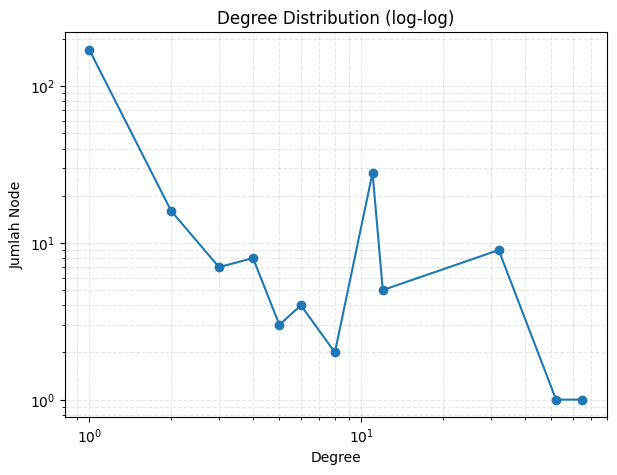

In [14]:
degree_vals = [d for _, d in G.degree()]
degree_counts = Counter(degree_vals)

deg, cnt = zip(*sorted(degree_counts.items()))

plt.figure(figsize=(7,5))
plt.loglog(deg, cnt, marker="o")
plt.xlabel("Degree")
plt.ylabel("Jumlah Node")
plt.title("Degree Distribution (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()


Deteksi Komunitas (Louvain Method)

In [15]:
from community import community_louvain

print("Menjalankan Louvain...")

partition = community_louvain.best_partition(G)
modularity = community_louvain.modularity(partition, G)
num_communities = len(set(partition.values()))

print("Jumlah Komunitas :", num_communities)
print("Modularity :", modularity)


Menjalankan Louvain...
Jumlah Komunitas : 45
Modularity : 0.46255157201018543


simpan

In [16]:
df_comm = pd.DataFrame(list(partition.items()), columns=["node", "community"])
df_comm = df_comm.sort_values(["community", "node"])
df_comm.to_csv("tesla_communities.csv", index=False)

print("tesla_communities.csv berhasil disimpan!")


tesla_communities.csv berhasil disimpan!


ukuran komunitas

In [17]:
summary = df_comm["community"].value_counts().sort_values(ascending=False)
summary


community
5     44
0     42
2     36
36    13
29    11
8      7
35     6
6      5
23     5
12     5
17     5
9      4
11     3
41     3
39     3
14     3
25     3
37     3
24     2
3      2
4      2
7      2
10     2
13     2
15     2
16     2
18     2
19     2
20     2
21     2
1      2
33     2
26     2
27     2
22     2
42     2
30     2
31     2
40     2
32     2
34     2
43     2
28     2
38     2
44     2
Name: count, dtype: int64

visualisasi jaringan komunitas

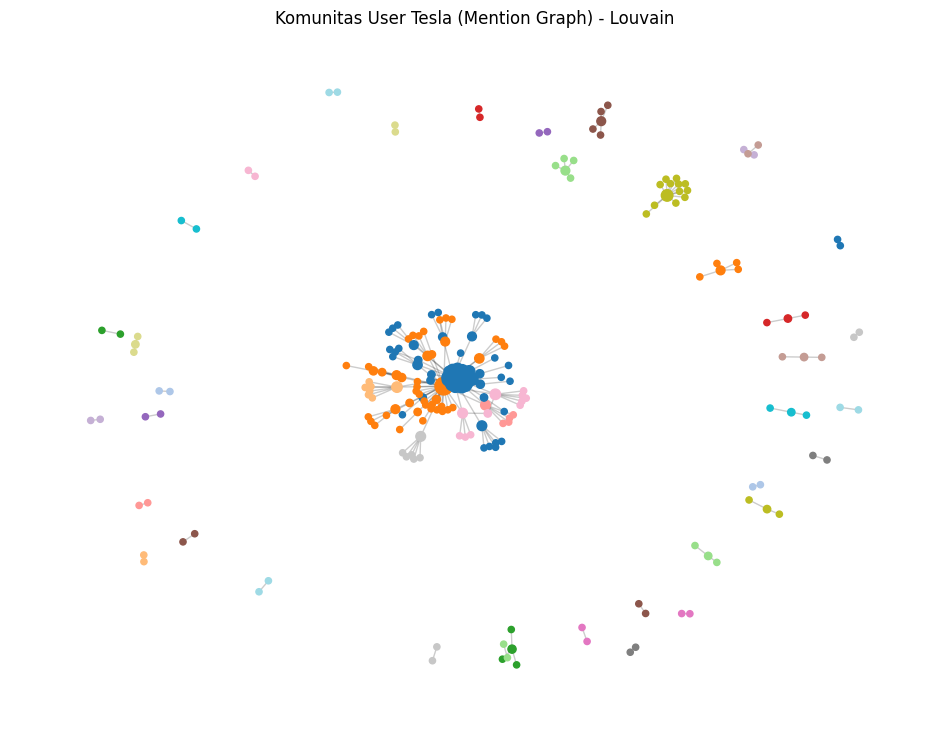

In [18]:
sub_nodes = list(degrees.keys())[:1000]
H = G.subgraph(sub_nodes)

pos = nx.spring_layout(H, seed=42)

communities = list(sorted(set(partition.values())))
mapping = {c: i for i, c in enumerate(communities)}
node_colors = [mapping[partition[n]] for n in H.nodes()]
node_sizes = [max(10, math.sqrt(dict(H.degree())[n])*20) for n in H.nodes()]

plt.figure(figsize=(12,9))
nx.draw_networkx_nodes(H, pos, node_color=node_colors, cmap=plt.get_cmap("tab20"), node_size=node_sizes)
nx.draw_networkx_edges(H, pos, alpha=0.2)
plt.title("Komunitas User Tesla (Mention Graph) - Louvain")
plt.axis("off")
plt.show()
